In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


In [2]:
from b_models.hsami.sequential_training_ring import train
train()

device: cuda
parameters: 416,396
run dir: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_ring/sequential_20260621_121502
=== Stage 1: denoiser_x unconditional (500 epochs) ===
[stage1] epoch     0 | step       0 | loss 1.0291 | lr 0.00e+00
[stage1] epoch    20 | step     100 | loss 1.0043 | lr 8.00e-05
[stage1] epoch    40 | step     200 | loss 0.5791 | lr 1.60e-04
[stage1] epoch    60 | step     300 | loss 0.5194 | lr 2.00e-04
[stage1] epoch    80 | step     400 | loss 0.4795 | lr 1.98e-04
saved checkpoint: /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_ring/sequential_20260621_121502/stage1_epoch_000100.pt
[stage1] epoch   100 | step     500 | loss 0.4736 | lr 1.95e-04
[stage1] epoch   120 | step     600 | loss 0.4613 | lr 1.89e-04
[stage1] epoch   140 | step     700 | loss 0.4855 | lr 1.83e-04
[stage1] epoch   160 | step     800 | loss 0.4623 | lr 1.75e-04
[stage1] epoch   180 | step     900 | loss 0.4454 | lr 1.65e-04
saved checkpoint: /mnt/cep

KeyboardInterrupt: 

['/jupyterlab-plotly/extension.js']


# stage 2

In [4]:
from b_models.hsami.recnet import RecNet
from b_models.hsami.hsami_alternate import HSAMI
from b_models.hsami.denoiser import Denoiser
from b_models.configs.hsami_config import HSAMI_Training_Config

checkpoint_path = "/mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_ring/sequential_20260620_140318/stage4_epoch_006000.pt"
checkpoint_dir = checkpoint_path.rsplit("/", 1)[0]
print(checkpoint_dir)
config = HSAMI_Training_Config()
config_path = checkpoint_dir + "/config.json"
config.load_from_json(config_path)

recnet = RecNet(config).to(device)

denoiser_x = Denoiser(
    config.input_dim, 
    hidden_dim=config.hidden_dim_x, 
    num_blocks=config.num_blocks_x, 
    time_dim=config.time_dim_x, 
    activation=config.activation
).to(device)

denoiser_y = Denoiser(
    config.latent_dim_y, 
    hidden_dim=config.hidden_dim_y, 
    num_blocks=config.num_blocks_y, 
    time_dim=config.time_dim_y, 
    activation=config.activation
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)


/mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_ring/sequential_20260620_140318


# conditional generation

In [5]:
from a_datasets.ring.data import WrappedPhaseRing, generate

dataset = WrappedPhaseRing(
    n=config.n,
    m=config.m,
    kappa=config.kappa,
    kappa_z=config.kappa_z,
    r0=config.r0,
    sigma=config.sigma,
    seed=config.seed,
)

x, y, z = generate(n=config.n,
    m=config.m,
    kappa=config.kappa,
    kappa_z=config.kappa_z,
    r0=config.r0,
    sigma=config.sigma,
    seed=config.seed,
)

# get a sample from the dataset
example_datum = x[0].to(device)
example_datum.shape

torch.Size([2])

In [6]:
# load x denoiser and x->y recnet
from b_models.hsami.sequential_training_ring import load_stage_checkpoint

checkpoint_dir = checkpoint_path.rsplit("/", 2)[0]
run_name = checkpoint_path.rsplit("/", 2)[1]
stage = 2
load_stage_checkpoint(hsami, checkpoint_dir, run_name, stage, device)

FileNotFoundError: No stage 2 checkpoints found in /mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_ring/sequential_20260620_140318

In [12]:
stage2_samples = hsami.stage2_generation(1000, example_datum.unsqueeze(0))
stage2_samples.shape

torch.Size([1000, 2])

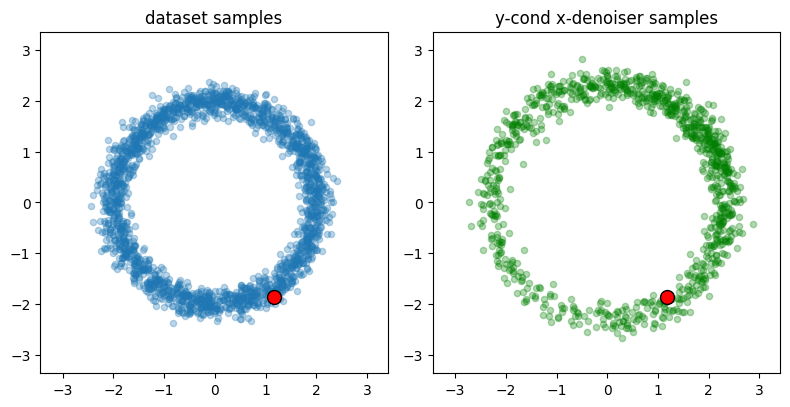

In [13]:
# plot the example datum among the dataset
x_cpu = x.cpu().numpy()[:2000]
example_datum_cpu = example_datum.cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].scatter(x_cpu[:, 0], x_cpu[:, 1], alpha=0.3, s=20, label='Dataset Samples')
ax[0].set_title('dataset samples')
ax[0].scatter(example_datum_cpu[0], example_datum_cpu[1], color='red', label='Example Datum', edgecolor='black', s=100)
# now plot the generated sample as well
stage2_samples_cpu = stage2_samples.detach().cpu().numpy()
ax[1].scatter(stage2_samples_cpu[:, 0], stage2_samples_cpu[:, 1], color='green', label='Generated Sample', alpha=0.3, s=20)
ax[1].set_title('y-cond x-denoiser samples')

ax[1].scatter(example_datum_cpu[0], example_datum_cpu[1], color='red', label='Example Datum', edgecolor='black', s=100)

# match axes
ax[0].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[0].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
ax[1].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[1].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
# set equal aspect ratio
plt.tight_layout()
ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')

# stage 4

In [2]:
from b_models.hsami.recnet import RecNet
from b_models.hsami.hsami_alternate import HSAMI
from b_models.hsami.denoiser import Denoiser
from b_models.configs.hsami_config import HSAMI_Training_Config

checkpoint_path = "/mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_ring/sequential_20260620_140318/stage4_epoch_006000.pt"
checkpoint_dir = checkpoint_path.rsplit("/", 1)[0]
print(checkpoint_dir)
config = HSAMI_Training_Config()
config_path = checkpoint_dir + "/config.json"
config.load_from_json(config_path)

recnet = RecNet(config).to(device)

denoiser_x = Denoiser(
    config.input_dim, 
    hidden_dim=config.hidden_dim_x, 
    num_blocks=config.num_blocks_x, 
    time_dim=config.time_dim_x, 
    activation=config.activation
).to(device)

denoiser_y = Denoiser(
    config.latent_dim_y, 
    hidden_dim=config.hidden_dim_y, 
    num_blocks=config.num_blocks_y, 
    time_dim=config.time_dim_y, 
    activation=config.activation
).to(device)

hsami = HSAMI(
    recnet=recnet,
    denoiser_x=denoiser_x,
    denoiser_y=denoiser_y,
    args=config
).to(device)

/mnt/ceph/users/blyo1/projects/hdiva/c_training/hsami_checkpoints_ring/sequential_20260620_140318


In [3]:
from a_datasets.ring.data import WrappedPhaseRing, generate

dataset = WrappedPhaseRing(
    n=config.n,
    m=config.m,
    kappa=config.kappa,
    kappa_z=config.kappa_z,
    r0=config.r0,
    sigma=config.sigma,
    seed=config.seed,
)

x, y, z = generate(n=config.n,
    m=config.m,
    kappa=config.kappa,
    kappa_z=config.kappa_z,
    r0=config.r0,
    sigma=config.sigma,
    seed=config.seed,
)

# get a sample from the dataset
example_datum = x[0].to(device)
example_datum.shape

torch.Size([2])

In [4]:
stage4_samples = hsami.conditional_generation(N=1000, target_x=example_datum.unsqueeze(0))
stage4_samples.shape

/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


torch.Size([1000, 2])

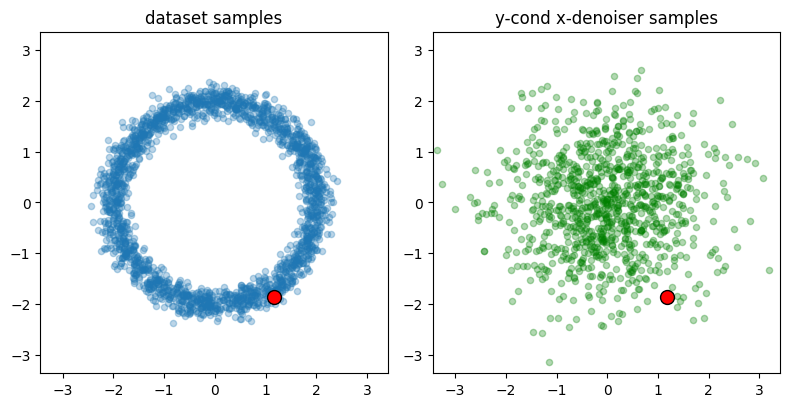

In [5]:
# plot the example datum among the dataset
x_cpu = x.cpu().numpy()[:2000]
example_datum_cpu = example_datum.cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 6))
ax[0].scatter(x_cpu[:, 0], x_cpu[:, 1], alpha=0.3, s=20, label='Dataset Samples')
ax[0].set_title('dataset samples')
ax[0].scatter(example_datum_cpu[0], example_datum_cpu[1], color='red', label='Example Datum', edgecolor='black', s=100)
# now plot the generated sample as well
stage4_samples_cpu = stage4_samples.detach().cpu().numpy()
ax[1].scatter(stage4_samples_cpu[:, 0], stage4_samples_cpu[:, 1], color='green', label='Generated Sample', alpha=0.3, s=20)
ax[1].set_title('y-cond x-denoiser samples')

ax[1].scatter(example_datum_cpu[0], example_datum_cpu[1], color='red', label='Example Datum', edgecolor='black', s=100)

# match axes
ax[0].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[0].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
ax[1].set_xlim(x_cpu[:, 0].min() - 1, x_cpu[:, 0].max() + 1)
ax[1].set_ylim(x_cpu[:, 1].min() - 1, x_cpu[:, 1].max() + 1)
# set equal aspect ratio
plt.tight_layout()
ax[0].set_aspect('equal', adjustable='box')
ax[1].set_aspect('equal', adjustable='box')